<a href="https://colab.research.google.com/github/omarcordero1/-omarcordero1/blob/main/OSINT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalamos librerías necesarias (si no están)
!pip install pandas matplotlib seaborn requests

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import requests
import hashlib

In [ ]:
# Si el archivo está en el entorno local
df = pd.read_csv('/content/2026-03-04T19-09_export.csv', index_col=0)
# Mostramos las primeras filas
df.head()

,FECHA,CUSTOMER,TX_TYPE,PRICE
0,2026-03-03,fmp19972003@gmail.com,purchase,"MXN1,390.00"
1,2026-03-03,carlosjose.ortega@hotmail.com,purchase,"MXN1,390.00"
2,2026-03-03,carmenquintanalvarez@gmail.com,purchase,MXN139.00
3,2026-03-03,citlalli.delapaz@gmail.com,purchase,MXN139.00
4,2026-03-03,abogadojacinto@hotmail.com,purchase,"MXN1,390.00"


In [ ]:
# Extraer dominio y nombre de usuario
df['dominio'] = df['CUSTOMER'].str.split('@').str[1]
df['usuario'] = df['CUSTOMER'].str.split('@').str[0]

# Limpiar precios: convertir a número
df['PRICE'] = df['PRICE'].astype(str).str.replace('MXN', '').str.replace(',', '').str.strip()
df['PRICE'] = pd.to_numeric(df['PRICE'], errors='coerce')

Distribución de dominios:
dominio
gmail.com                   12
hotmail.com                  9
yahoo.com                    3
privaterelay.appleid.com     1
badenpowell.edu.mx           1
aefcm.gob.mx                 1
cazarin.com.mx               1
Name: count, dtype: int64


/tmp/ipykernel_461/3234147711.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dominios.values, y=dominios.index, palette='viridis')


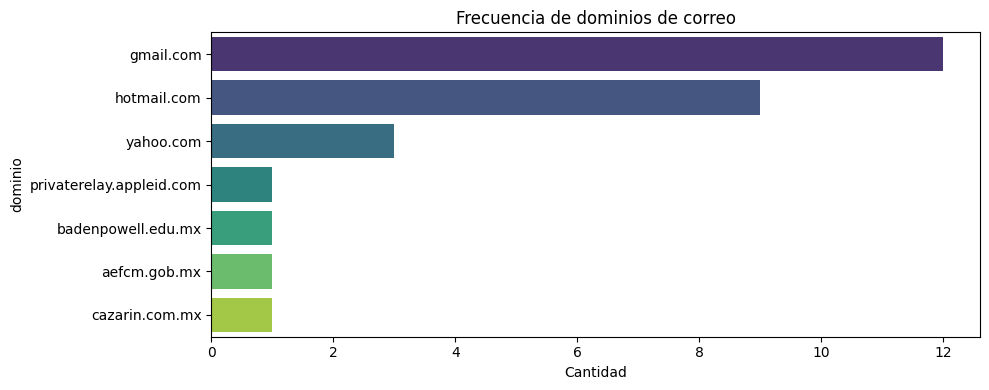

In [ ]:
# Frecuencia de dominios
dominios = df['dominio'].value_counts()
print("Distribución de dominios:")
print(dominios)

# Gráfico
plt.figure(figsize=(10,4))
sns.barplot(x=dominios.values, y=dominios.index, palette='viridis')
plt.title('Frecuencia de dominios de correo')
plt.xlabel('Cantidad')
plt.tight_layout()
plt.show()

In [ ]:
# Función para extraer posibles palabras significativas
def extraer_palabras(usuario):
    # Separar por puntos, guiones, números, etc.
    partes = re.split(r'[.\-_]', usuario)
    palabras = []
    for p in partes:
        # Ignorar partes puramente numéricas o muy cortas
        if p.isalpha() and len(p) > 2:
            palabras.append(p.lower())
        # También capturar números que parezcan años (1900-2025)
        if p.isdigit() and len(p) == 4 and 1900 <= int(p) <= 2025:
            palabras.append('año_' + p)
    return palabras

# Aplicar a todos los usuarios
todas_palabras = []
for usuario in df['usuario']:
    todas_palabras.extend(extraer_palabras(usuario))

# Contar frecuencias
frec_palabras = Counter(todas_palabras).most_common(20)
print("Palabras más frecuentes en nombres de usuario:")
for palabra, count in frec_palabras:
    print(f"  {palabra}: {count}")

Palabras más frecuentes en nombres de usuario:
  carlosjose: 1
  ortega: 1
  carmenquintanalvarez: 1
  citlalli: 1
  delapaz: 1
  abogadojacinto: 1
  roydipi: 1
  michusnikon: 1
  alexhkgz: 1
  lyydmar: 1
  rodrigo: 1
  mtz: 1
  rosas: 1
  riveradelatorre: 1
  juanalvarocastro: 1
  vlara: 1
  enavacou: 1
  joel: 1
  meza: 1
  año_1970: 1


In [ ]:
diccionario_intereses = {
    'abogado': 'Derecho',
    'monitoreo': 'Seguridad/Vigilancia',
    'michus': 'Mascotas (gatos)',
    'deporte': 'Deportes',
    'futbol': 'Deportes',
    'musica': 'Música',
    'tecnologia': 'Tecnología',
    'programacion': 'Tecnología',
    'gamer': 'Videojuegos',
    'viajes': 'Viajes'
}

intereses_encontrados = []
for usuario in df['usuario']:
    usuario_lower = usuario.lower()
    for clave, categoria in diccionario_intereses.items():
        if clave in usuario_lower:
            intereses_encontrados.append(categoria)

frec_intereses = Counter(intereses_encontrados).most_common()
print("Posibles intereses detectados:")
for cat, count in frec_intereses:
    print(f"  {cat}: {count}")

Posibles intereses detectados:
  Derecho: 1
  Mascotas (gatos): 1
  Seguridad/Vigilancia: 1


In [ ]:
def check_hibp(email):
    # Convertir email a SHA1 y tomar los primeros 5 caracteres
    sha1 = hashlib.sha1(email.encode('utf-8')).hexdigest().upper()
    prefix = sha1[:5]
    suffix = sha1[5:]
    url = f"https://api.pwnedpasswords.com/range/{prefix}"
    response = requests.get(url)
    if response.status_code == 200:
        hashes = (line.split(':') for line in response.text.splitlines())
        for h, count in hashes:
            if h == suffix:
                return int(count)
    return 0

# Probamos con los primeros 5 emails (para no saturar)
for email in df['CUSTOMER'].head():
    count = check_hibp(email)
    if count > 0:
        print(f"{email} aparece en {count} filtraciones.")
    else:
        print(f"{email} no aparece en filtraciones conocidas.")
    # Pequeña pausa para no abusar
    import time
    time.sleep(1.5)

fmp19972003@gmail.com no aparece en filtraciones conocidas.
carlosjose.ortega@hotmail.com no aparece en filtraciones conocidas.
carmenquintanalvarez@gmail.com no aparece en filtraciones conocidas.
citlalli.delapaz@gmail.com no aparece en filtraciones conocidas.
abogadojacinto@hotmail.com no aparece en filtraciones conocidas.


In [ ]:
# Agrupar por dominio y precio
cruzada = pd.crosstab(df['dominio'], df['PRICE'])
print("Tabla de dominios vs precio:")
print(cruzada)

Tabla de dominios vs precio:
PRICE                     139.0   1390.0
dominio                                 
aefcm.gob.mx                   1       0
badenpowell.edu.mx             1       0
cazarin.com.mx                 1       0
gmail.com                      9       3
hotmail.com                    7       2
privaterelay.appleid.com       1       0
yahoo.com                      2       1
